# Exploratory Data Analysis - Short-form Content

## Objetivo
Analisar fatores que influenciam a viralização de vídeos curtos (Tiktok e Youtube Shorts)

## Perguntas principais:
- O que mais impacta views?
- Retenção importa?
- Existe horário ideal?
- Quais as diferenças entre plataformas?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/external/youtube_shorts_tiktok_trends_2025.csv")

df.head()

,platform,country,region,language,category,hashtag,title_keywords,author_handle,sound_type,music_track,...,traffic_source,is_weekend,row_id,engagement_total,like_rate,dislike_rate,engagement_per_1k,engagement_like_rate,engagement_comment_rate,engagement_share_rate
0,TikTok,Jp,Asia,ja,Gaming,#Lifestyle,Night Routine — College,NextVision,trending,8bit loop,...,External,1,2e681528d17a1fe1986857942536ec27,30317,0.086159,0.004004,120.069,0.086159,0.012555,0.007830
1,TikTok,Se,Europe,sv,Food,#Sports,Morning Routine — College,DailyVlogsDiego,trending,Street vibe,...,Search,0,2e35fa0b2978b9cae635839c1d4e9e74,30577,0.085298,0.002421,113.005,0.085298,0.007850,0.007791
2,TikTok,Za,Africa,en,Art,#Workout,Night Routine — College,BeyondHub,licensed,Gallery pad,...,External,1,0d88a011235a82244995ef52961f9502,503,0.049154,0.001625,68.111,0.049154,0.004469,0.005146
3,TikTok,Kr,Asia,ko,News,#Esports,Best Settings for Fortnite,NextHub,original,Neutral piano,...,Search,1,e15cff7621ed3f9eb9d2c97c841be0f3,7828,0.086257,0.003164,108.156,0.086257,0.011205,0.005292
4,TikTok,Au,Oceania,en,Beauty,#Comedy,When your friend is Beginners,LucasOfficial,licensed,Soft glam loop,...,ForYou,1,d696b4f0a50ea70e7cb5021be7e198ec,1171,0.051441,0.001175,72.400,0.051441,0.004204,0.004142


In [8]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 48079 entries, 0 to 48078
Data columns (total 58 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   platform                 48079 non-null  str    
 1   country                  48079 non-null  str    
 2   region                   48079 non-null  str    
 3   language                 48079 non-null  str    
 4   category                 48079 non-null  str    
 5   hashtag                  48079 non-null  str    
 6   title_keywords           48079 non-null  str    
 7   author_handle            48079 non-null  str    
 8   sound_type               48079 non-null  str    
 9   music_track              48079 non-null  str    
 10  week_of_year             48079 non-null  int64  
 11  duration_sec             48079 non-null  int64  
 12  views                    48079 non-null  int64  
 13  likes                    48079 non-null  int64  
 14  comments                 48079 no

,week_of_year,duration_sec,views,likes,comments,shares,saves,engagement_rate,upload_hour,trend_duration_days,...,avg_watch_time_sec,completion_rate,is_weekend,engagement_total,like_rate,dislike_rate,engagement_per_1k,engagement_like_rate,engagement_comment_rate,engagement_share_rate
count,48079.000000,48079.000000,4.807900e+04,48079.000000,48079.000000,48079.000000,48079.000000,48079.000000,48079.000000,48079.000000,...,48079.000000,48079.000000,48079.000000,48079.000000,48079.000000,48079.000000,48079.000000,48079.000000,48079.000000,48079.000000
mean,18.234260,34.489320,9.929276e+04,5737.732108,628.657314,553.484494,591.071487,0.075415,15.986751,13.742923,...,21.662460,0.635308,0.622995,7510.945402,0.057607,0.002462,75.415322,0.057607,0.006310,0.005556
std,9.996924,16.401608,1.318522e+05,8639.923653,967.782704,849.436172,978.280616,0.030091,5.489399,13.343582,...,10.583019,0.112604,0.484641,11262.284575,0.023123,0.001586,30.090519,0.023123,0.002969,0.002496
min,1.000000,5.000000,7.940000e+02,33.000000,3.000000,3.000000,2.000000,0.014720,0.000000,3.000000,...,2.800000,0.400000,0.000000,43.000000,0.011792,0.000000,14.720000,0.011792,0.000975,0.000735
25%,10.000000,22.000000,3.032250e+04,1526.000000,160.000000,143.000000,138.000000,0.052326,13.000000,5.000000,...,14.000000,0.548000,0.000000,1998.000000,0.039941,0.001273,52.326000,0.039941,0.004058,0.003670
50%,18.000000,31.000000,5.962000e+04,3167.000000,339.000000,301.000000,301.000000,0.071575,17.000000,7.000000,...,19.400000,0.635000,1.000000,4159.000000,0.054654,0.002138,71.575000,0.054654,0.005809,0.005163
75%,27.000000,43.000000,1.180945e+05,6618.000000,720.000000,635.000000,659.500000,0.094794,20.000000,17.000000,...,27.000000,0.724000,1.000000,8675.000000,0.072280,0.003276,94.793500,0.072281,0.008016,0.007000
max,35.000000,90.000000,3.080686e+06,310916.000000,31776.000000,29004.000000,29679.000000,0.235819,23.000000,60.000000,...,67.300000,0.850000,1.000000,390142.000000,0.185300,0.012718,235.819000,0.185300,0.023668,0.020328


In [7]:
df.columns

Index(['platform', 'country', 'region', 'language', 'category', 'hashtag',
       'title_keywords', 'author_handle', 'sound_type', 'music_track',
       'week_of_year', 'duration_sec', 'views', 'likes', 'comments', 'shares',
       'saves', 'engagement_rate', 'trend_label', 'source_hint', 'notes',
       'device_type', 'upload_hour', 'genre', 'trend_duration_days',
       'trend_type', 'engagement_velocity', 'dislikes', 'comment_ratio',
       'share_rate', 'save_rate', 'like_dislike_ratio', 'publish_dayofweek',
       'publish_period', 'event_season', 'tags', 'sample_comments',
       'creator_avg_views', 'creator_tier', 'season', 'publish_date_approx',
       'year_month', 'title', 'title_length', 'has_emoji',
       'avg_watch_time_sec', 'completion_rate', 'device_brand',
       'traffic_source', 'is_weekend', 'row_id', 'engagement_total',
       'like_rate', 'dislike_rate', 'engagement_per_1k',
       'engagement_like_rate', 'engagement_comment_rate',
       'engagement_share_rate'

Não há dados faltantes

In [9]:
df.isnull().sum()

platform                   0
country                    0
region                     0
language                   0
category                   0
hashtag                    0
title_keywords             0
author_handle              0
sound_type                 0
music_track                0
week_of_year               0
duration_sec               0
views                      0
likes                      0
comments                   0
shares                     0
saves                      0
engagement_rate            0
trend_label                0
source_hint                0
notes                      0
device_type                0
upload_hour                0
genre                      0
trend_duration_days        0
trend_type                 0
engagement_velocity        0
dislikes                   0
comment_ratio              0
share_rate                 0
save_rate                  0
like_dislike_ratio         0
publish_dayofweek          0
publish_period             0
event_season  

### Engamento vs Views

Objetivo: entender como métricas de engajamento influenciam nas visualizações.

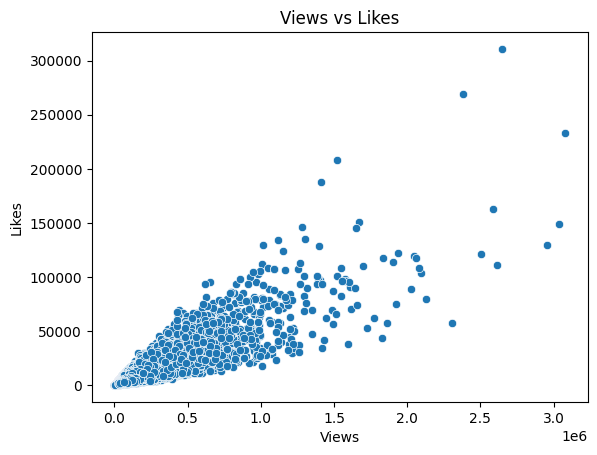

In [11]:
sns.scatterplot(data=df, x="views", y="likes")
plt.title("Views vs Likes")
plt.xlabel("Views")
plt.ylabel("Likes")
plt.show()

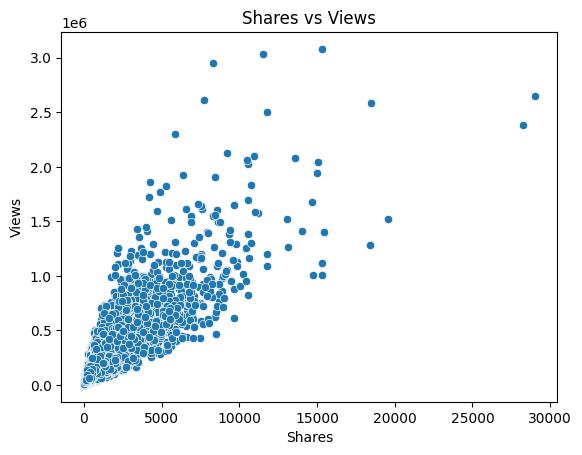

In [12]:
sns.scatterplot(data=df,x="shares", y="views")
plt.title("Shares vs Views")
plt.xlabel("Shares")
plt.ylabel("Views")
plt.show()

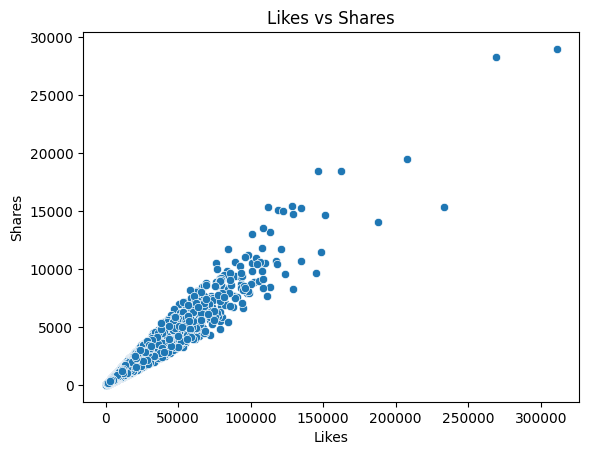

In [13]:
sns.scatterplot(data=df, x="likes", y="shares")
plt.title("Likes vs Shares")
plt.xlabel("Likes")
plt.ylabel("Shares")
plt.show()

### Comparação entre plataformas

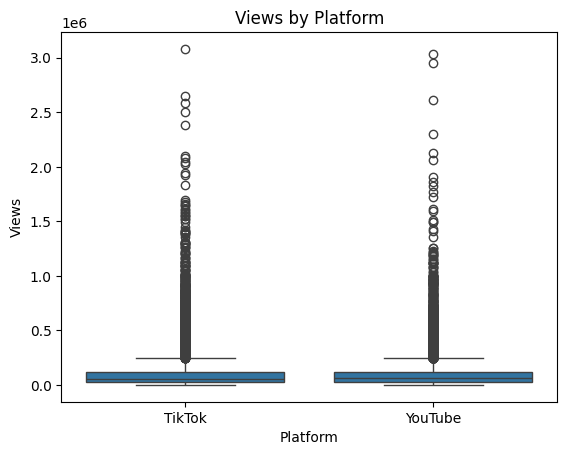

In [14]:
sns.boxplot(data=df, x="platform", y="views")
plt.title("Views by Platform")
plt.xlabel("Platform")
plt.ylabel("Views")
plt.show()

### Conteúdo

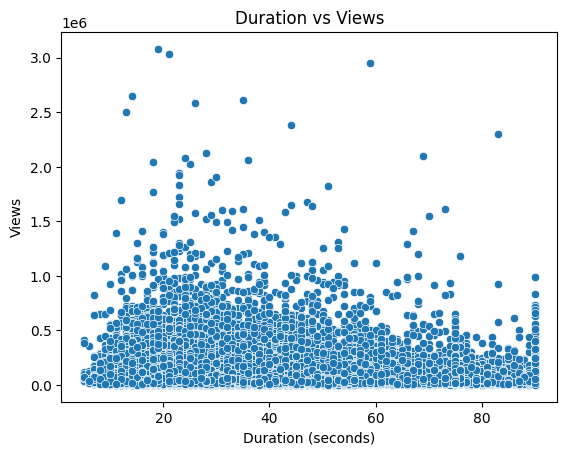

In [16]:
sns.scatterplot(data=df, x="duration_sec", y="views")
plt.title("Duration vs Views")
plt.xlabel("Duration (seconds)")
plt.ylabel("Views")
plt.show()

Apenas a hashtag principal é disponibilizada na base de dados

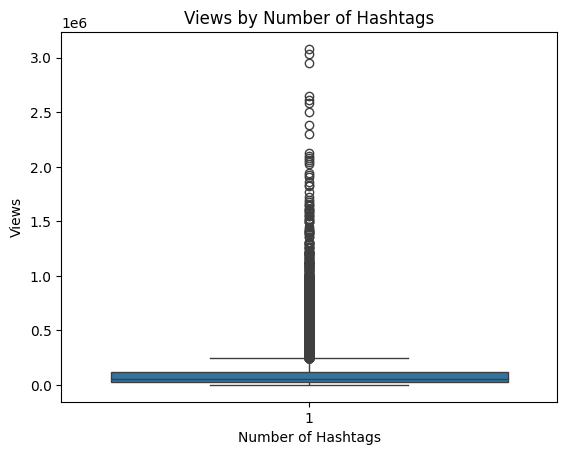

In [21]:
df["num_hashtags"] = df["hashtag"].apply(lambda x: len(str(x).split()))
sns.boxplot(data=df, x="num_hashtags", y="views")
plt.title("Views by Number of Hashtags")
plt.xlabel("Number of Hashtags")
plt.ylabel("Views")
plt.show()

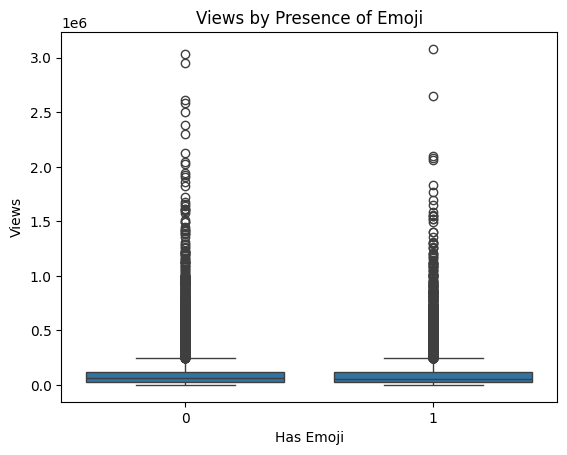

In [34]:
sns.boxplot(data=df, x="has_emoji", y="views")
plt.title("Views by Presence of Emoji")
plt.xlabel("Has Emoji")
plt.ylabel("Views")
plt.show()

### Tempo

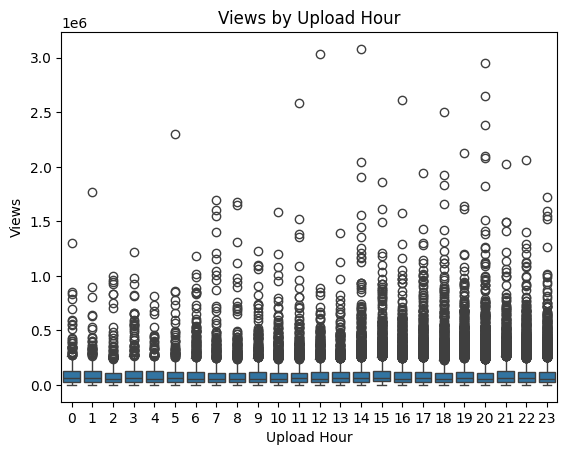

In [24]:
sns.boxplot(data=df, x="upload_hour", y="views")
plt.title("Views by Upload Hour")
plt.xlabel("Upload Hour")
plt.ylabel("Views")
plt.show()

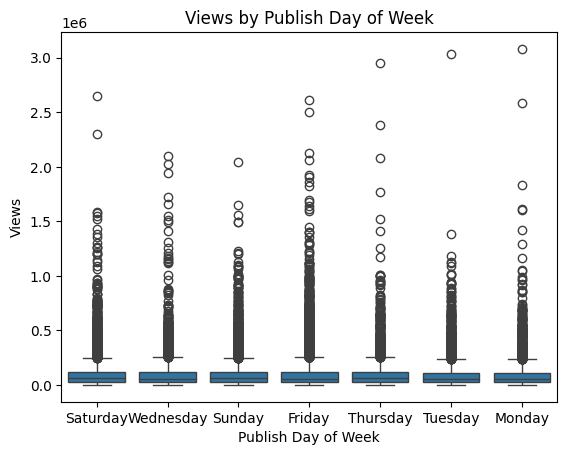

In [28]:
sns.boxplot(data=df, x="publish_dayofweek", y="views")
# plt.xticks(rotation=45)
plt.title("Views by Publish Day of Week")
plt.xlabel("Publish Day of Week")
plt.ylabel("Views")
plt.show()

### Criador

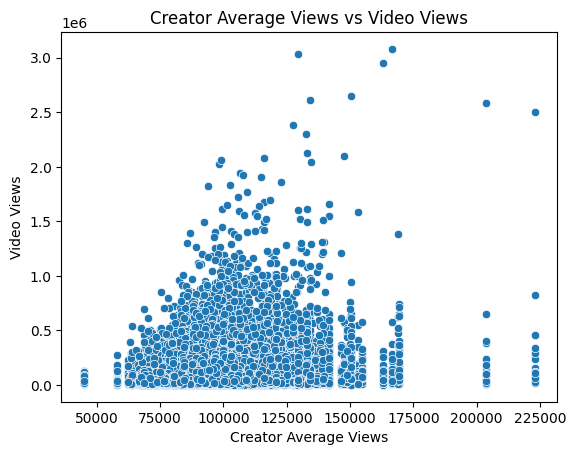

In [29]:
sns.scatterplot(data=df, x="creator_avg_views", y="views")
plt.title("Creator Average Views vs Video Views")
plt.xlabel("Creator Average Views")
plt.ylabel("Video Views")
plt.show()

### Métricas Avançadas

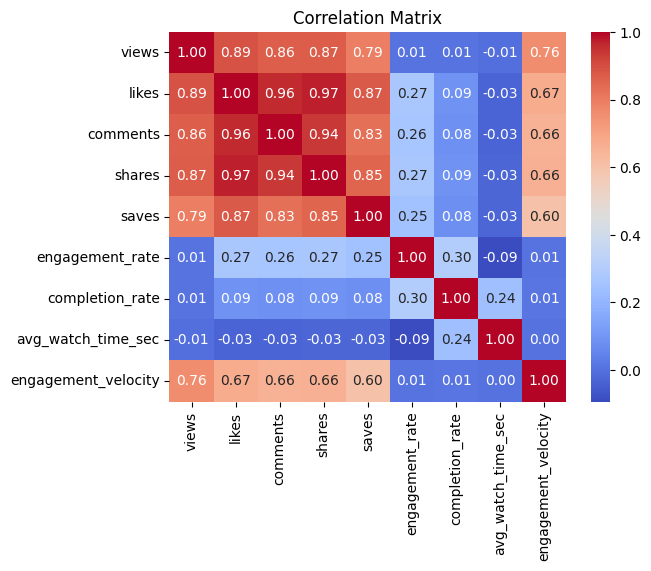

In [22]:
cols = [
    "views", "likes", "comments", "shares", "saves",
    "engagement_rate", "completion_rate",
    "avg_watch_time_sec", "engagement_velocity"
]

corr = df[cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

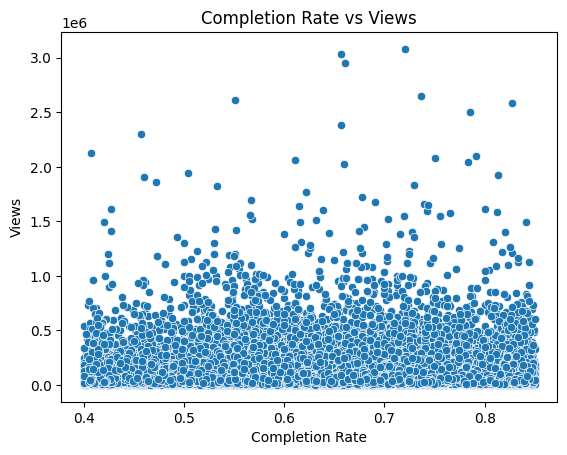

In [23]:
sns.scatterplot(data=df, x="completion_rate", y="views")
plt.title("Completion Rate vs Views")
plt.xlabel("Completion Rate")
plt.ylabel("Views")
plt.show()

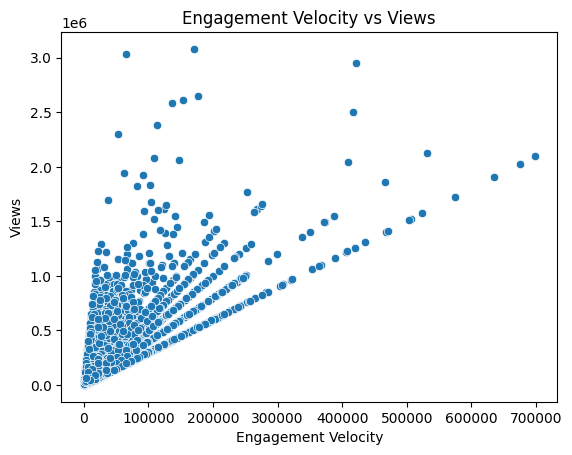

In [31]:
sns.scatterplot(data=df, x="engagement_velocity", y="views")
plt.title("Engagement Velocity vs Views")
plt.xlabel("Engagement Velocity")
plt.ylabel("Views")
plt.show()

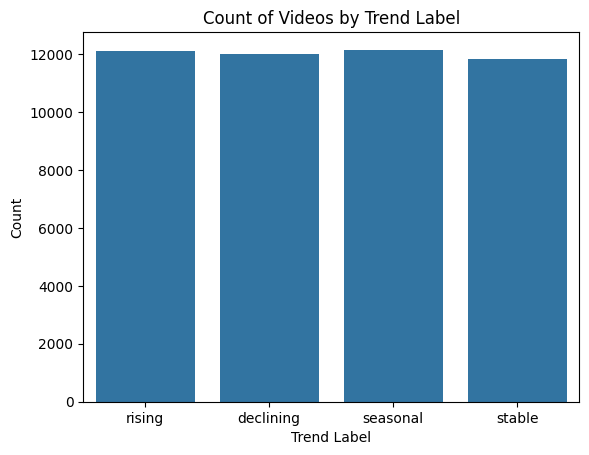

In [32]:
sns.countplot(data=df, x="trend_label")
plt.title("Count of Videos by Trend Label")
plt.xlabel("Trend Label")
plt.ylabel("Count")
plt.show()